In [ ]:
import pandas as pd

df = pd.read_csv('spg.csv')

print("=== GÖREV 1: VERİ Ön İşleme ===")

satir_sayisi, sutun_sayisi = df.shape
print(f"Veri Setindeki Toplam Veri Sayısı (Satır): {satir_sayisi}")
print(f"Veri Setindeki Toplam Sütun Sayısı (Sütun): {sutun_sayisi}")

print("\n--- Veri Setindeki Sütunların İsimleri ---")
print(df.columns.tolist())

=== GÖREV 1: VERİ Ön İşleme ===
Veri Setindeki Toplam Veri Sayısı (Satır): 4215
Veri Setindeki Toplam Sütun Sayısı (Sütun): 21

--- Veri Setindeki Sütunların İsimleri ---
['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd', 'mean_sea_level_pressure_MSL', 'total_precipitation_sfc', 'snowfall_amount_sfc', 'total_cloud_cover_sfc', 'high_cloud_cover_high_cld_lay', 'medium_cloud_cover_mid_cld_lay', 'low_cloud_cover_low_cld_lay', 'shortwave_radiation_backwards_sfc', 'wind_speed_10_m_above_gnd', 'wind_direction_10_m_above_gnd', 'wind_speed_80_m_above_gnd', 'wind_direction_80_m_above_gnd', 'wind_speed_900_mb', 'wind_direction_900_mb', 'wind_gust_10_m_above_gnd', 'angle_of_incidence', 'zenith', 'azimuth', 'generated_power_kw']


In [67]:
print("=== TEKRAR EDEN VE EKSİK VERİ ANALİZİ ===")

tekrar_edenler = df[df.duplicated(keep=False)]
tekrar_sayisi = df.duplicated().sum()

print(f"Veri setindeki tekrar eden satır sayısı: {tekrar_sayisi}\n")

if tekrar_sayisi > 0:
    print("Tekrar Eden Satırların Eşleşmeleri: ")
    gruplanmis = tekrar_edenler.groupby(list(df.columns))
    for _, grup in gruplanmis:
        normal_satirlar = [str(idx + 1) for idx in grup.index]
        print(f" -> Satır {' ve '.join(normal_satirlar)} birbiriyle tamamen aynı.")

    df = df.drop_duplicates()
    print("\n-> Tekrar eden satırlar temizlendi, verinin tekil hali bırakıldı.")
else:
    print("-> Veri setinde tekrar eden hiç satır yok.")

print("\n--- Sütunlardaki Eksik (Boş) Veri Sayıları ---")
eksik_veriler = df.isnull().sum()
print(eksik_veriler)

toplam_eksik = eksik_veriler.sum()
print(f"\nToplam eksik veri sayısı: {toplam_eksik}")

if toplam_eksik > 0:
    df = df.dropna()
    print("-> Eksik veri içeren satırlar temizlendi.")
else:
    print("-> Veri setinde hiçbir eksik/boş değer bulunmuyor.")

=== TEKRAR EDEN VE EKSİK VERİ ANALİZİ ===
Veri setindeki tekrar eden satır sayısı: 2

Tekrar Eden Satırların Eşleşmeleri: 
 -> Satır 4213 ve 4214 birbiriyle tamamen aynı.
 -> Satır 4212 ve 4215 birbiriyle tamamen aynı.

-> Tekrar eden satırlar temizlendi, verinin tekil hali bırakıldı.

--- Sütunlardaki Eksik (Boş) Veri Sayıları ---
temperature_2_m_above_gnd            0
relative_humidity_2_m_above_gnd      0
mean_sea_level_pressure_MSL          0
total_precipitation_sfc              0
snowfall_amount_sfc                  0
total_cloud_cover_sfc                0
high_cloud_cover_high_cld_lay        0
medium_cloud_cover_mid_cld_lay       0
low_cloud_cover_low_cld_lay          0
shortwave_radiation_backwards_sfc    0
wind_speed_10_m_above_gnd            0
wind_direction_10_m_above_gnd        0
wind_speed_80_m_above_gnd            0
wind_direction_80_m_above_gnd        0
wind_speed_900_mb                    0
wind_direction_900_mb                0
wind_gust_10_m_above_gnd             0
ang

In [68]:
import numpy as np

muaf_sutunlar = ['total_precipitation_sfc', 'snowfall_amount_sfc', 'shortwave_radiation_backwards_sfc', 'generated_power_kw']

sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns
toplam_aykiri_sayisi = 0

for col in sayisal_sutunlar:
    if col in muaf_sutunlar:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        continue

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    aykiri_sayisi = ((df[col] < alt_sinir) | (df[col] > ust_sinir)).sum()

    if aykiri_sayisi > 0:
        print(f"-> '{col}' sütununda {aykiri_sayisi} adet gerçek aykırı değer (uç değer) düzeltildi.")
        toplam_aykiri_sayisi += aykiri_sayisi

        df[col] = np.where(df[col] < alt_sinir, alt_sinir, df[col])
        df[col] = np.where(df[col] > ust_sinir, ust_sinir, df[col])

print(f"\n Toplam {toplam_aykiri_sayisi} adet gerçek aykırı değer temizlendi.")

-> 'mean_sea_level_pressure_MSL' sütununda 45 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'high_cloud_cover_high_cld_lay' sütununda 773 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'medium_cloud_cover_mid_cld_lay' sütununda 959 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'low_cloud_cover_low_cld_lay' sütununda 955 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'wind_speed_10_m_above_gnd' sütununda 101 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'wind_speed_80_m_above_gnd' sütununda 74 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'wind_speed_900_mb' sütununda 103 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'wind_gust_10_m_above_gnd' sütununda 127 adet gerçek aykırı değer (uç değer) düzeltildi.
-> 'zenith' sütununda 10 adet gerçek aykırı değer (uç değer) düzeltildi.

 Toplam 3147 adet gerçek aykırı değer temizlendi.


In [69]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor

y = df['generated_power_kw']
X = df.drop(columns=['generated_power_kw'])

print(f"Orijinal Özellik Sayısı: {X.shape[1]}")

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("-> Veriler Min-Max Scaling yöntemiyle [0, 1] arasına başarıyla normalize edildi.\n")

print("Yöntem 1: Korelasyon Katsayısı ile En İyi Özellikler")
korelasyonlar = X_scaled.apply(lambda col: y.corr(col)).abs().sort_values(ascending=False)
print("Elektrik üretimiyle en ilişkili ilk 5 sütun:")
print(korelasyonlar.head(5))
print("-" * 50)

print("Yöntem 2: SelectKBest (İstatistiki F-Skor) ile En İyi Özellikler")
selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X_scaled, y)
ham_f_skorlari = pd.Series(selector.scores_, index=X.columns)
normalize_f_skorlari = (ham_f_skorlari - ham_f_skorlari.min()) / (ham_f_skorlari.max() - ham_f_skorlari.min())
f_skorlari = normalize_f_skorlari.sort_values(ascending=False)

print("F-Skoruna göre en önemli ilk 5 sütun (0-1 Arası Normalize Edilmiş):")
print(f_skorlari.head(5))
print("-" * 50)
print("Yöntem 3: Karar Ağacı (Decision Tree) Öznitelik Önem Dereceleri")
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_scaled, y)
agac_skorlari = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Karar Ağacına göre en önemli ilk 5 sütun:")
print(agac_skorlari.head(5))
print("-" * 50)
en_iyi_ozellikler = list(agac_skorlari.head(5).index)

print(f"\n3 Farklı Yöntemin Analizi Sonucunda Seçilen Ortak En Kritik Özellikler:")
for i, feat in enumerate(en_iyi_ozellikler, 1):
    print(f" {i}. {feat}")

X_final = X_scaled[en_iyi_ozellikler]
print(f"\nVeri seti temizlendi. Özellik sayısı {X.shape[1]}'den {X_final.shape[1]}'e indirgendi.")

Orijinal Özellik Sayısı: 20
-> Veriler Min-Max Scaling yöntemiyle [0, 1] arasına başarıyla normalize edildi.

Yöntem 1: Korelasyon Katsayısı ile En İyi Özellikler
Elektrik üretimiyle en ilişkili ilk 5 sütun:
zenith                               0.650296
angle_of_incidence                   0.646537
shortwave_radiation_backwards_sfc    0.556148
relative_humidity_2_m_above_gnd      0.336783
total_cloud_cover_sfc                0.334338
dtype: float64
--------------------------------------------------
Yöntem 2: SelectKBest (İstatistiki F-Skor) ile En İyi Özellikler
F-Skoruna göre en önemli ilk 5 sütun (0-1 Arası Normalize Edilmiş):
zenith                               1.000000
angle_of_incidence                   0.980126
shortwave_radiation_backwards_sfc    0.609819
relative_humidity_2_m_above_gnd      0.171815
total_cloud_cover_sfc                0.168962
dtype: float64
--------------------------------------------------
Yöntem 3: Karar Ağacı (Decision Tree) Öznitelik Önem Dereceleri
Kar

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print(f"Eğitim Veri Seti Boyutu: {X_train.shape[0]} satır")
print(f"Test Veri Seti Boyutu: {X_test.shape[0]} satır\n")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

metrik_sonuclari = []
modeller = {
    "Lineer Regresyon": lr_model,
    "Karar Ağacı Regresörü": dt_model,
    "KNN Regresörü": knn_model
}

for isim, model in modeller.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)

    mae_train = mean_absolute_error(y_train, train_pred)
    mae_test = mean_absolute_error(y_test, test_pred)

    rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))

    metrik_sonuclari.append({
        "Model": isim,
        "Eğitim R2 (Başarı)": f"%{r2_train*100:.2f}",
        "Test R2 (Başarı)": f"%{r2_test*100:.2f}",
        "Eğitim MAE (Hata kW)": f"{mae_train:.2f}",
        "Test MAE (Hata kW)": f"{mae_test:.2f}",
        "Eğitim RMSE (Hata kW)": f"{rmse_train:.2f}",
        "Test RMSE (Hata kW)": f"{rmse_test:.2f}"
    })
df_performans = pd.DataFrame(metrik_sonuclari)
print("MODELLERİN EĞİTİM VE TEST PERFORMANS KARŞILAŞTIRMASI:")
display(df_performans)

print("\n" + "="*60)
print("EN UYGUN MODELİN SEÇİLMESİ VE GEREKÇESİ:")
df_performans['test_r2_numeric'] = df_performans['Test R2 (Başarı)'].str.replace('%','').astype(float)
en_iyi_row = df_performans.loc[df_performans['test_r2_numeric'].idxmax()]

print(f"Veri Seti için En Uygun Model: {en_iyi_row['Model']}")
print(f"Gerekçe: Test veri setinde en yüksek açıklayıcılık oranına ({en_iyi_row['Test R2 (Başarı)']}) "
      f"ve en düşük ortalama hataya ({en_iyi_row['Test MAE (Hata kW)']} kW) bu model ulaşmıştır.")
print("="*60)

Eğitim Veri Seti Boyutu: 3370 satır
Test Veri Seti Boyutu: 843 satır

MODELLERİN EĞİTİM VE TEST PERFORMANS KARŞILAŞTIRMASI:


,Model,Eğitim R2 (Başarı),Test R2 (Başarı),Eğitim MAE (Hata kW),Test MAE (Hata kW),Eğitim RMSE (Hata kW),Test RMSE (Hata kW)
0,Lineer Regresyon,%67.60,%69.66,411.38,402.40,531.26,526.43
1,Karar Ağacı Regresörü,%74.29,%73.52,320.75,330.20,473.27,491.81
2,KNN Regresörü,%81.66,%75.36,242.73,295.48,399.71,474.46



EN UYGUN MODELİN SEÇİLMESİ VE GEREKÇESİ:
Veri Seti için En Uygun Model: KNN Regresörü
Gerekçe: Test veri setinde en yüksek açıklayıcılık oranına (%75.36) ve en düşük ortalama hataya (295.48 kW) bu model ulaşmıştır.


=== GÖREV 4: KARA KUTU MODEL AÇIKLANABİLİRLİĞİ (SHAP) ===
SHAP değerleri hesaplanıyor, bu işlem 1-2 dakika sürebilir, bekle aga...


  0%|          | 0/100 [00:00<?, ?it/s]

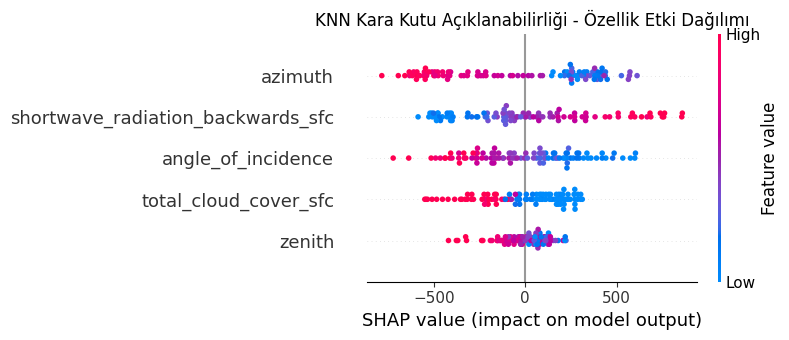


SHAP Kara Kutu analizi tamamlandı!


In [72]:
!pip install shap
import shap
import matplotlib.pyplot as plt

print("=== GÖREV 4: KARA KUTU MODEL AÇIKLANABİLİRLİĞİ (SHAP) ===")

X_train_summary = shap.kmeans(X_train, 100)
explainer = shap.KernelExplainer(knn_model.predict, X_train_summary)

print("SHAP değerleri hesaplanıyor, bu işlem 1-2 dakika sürebilir, bekle aga...")
shap_values = explainer.shap_values(X_test.iloc[:100])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:100], show=False)
plt.title("KNN Kara Kutu Açıklanabilirliği - Özellik Etki Dağılımı")
plt.tight_layout()
plt.show()

print("\nSHAP Kara Kutu analizi tamamlandı!")

In [62]:
!pip install streamlit==1.22.0 -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 4s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [63]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np

st.set_page_config(page_title="GES Elektrik Üretim Tahmini", layout="centered")
st.title("☀️ Güneş Enerjisi Santrali (GES) Güç Tahmin Sistemi")
st.markdown("Hava durumu verilerini girerek üretilecek elektrik miktarını (kW) tahmin edin.")

@st.cache_resource
def load_models():
    model = joblib.load('knn_sampiyon_model.pkl')
    features = joblib.load('kullanilan_ozellikler.pkl')
    return model, features

model, selected_features = load_models()

feature_mapping = {
    'angle_of_incidence': 'angle_of_incidence (Güneş Işığının Geliş Açısı)',
    'total_cloud_cover_sfc': 'total_cloud_cover_sfc (Toplam Bulutluluk Oranı)',
    'azimut': 'azimut (Azimut Açısı / Güneş Yönü)',
    'shortwave_radiation_backwards_sfc': 'shortwave_radiation_backwards_sfc (Kısa Dalga Güneş Radyasyonu)',
    'zenit': 'zenit (Zenit Açısı / Tepe Açısı)'
}

st.subheader("Hava Durumu Parametrelerini Girin")
user_inputs = {}

for feature in selected_features:
    display_name = feature_mapping.get(feature, feature)
    user_inputs[feature] = st.number_input(f"{display_name} değerini girin:", value=0.0)

if st.button("Üretimi Tahmin Et"):
    try:
        input_data = pd.DataFrame([user_inputs])
        tahmin = model.predict(input_data)[0]
        st.success(f"Beklenen Elektrik Üretimi: {tahmin:.2f} kW")
    except Exception as e:
        st.error(f"Hata oluştu: {e}")

Overwriting app.py


In [65]:
!streamlit run app.py & cloudflared tunnel --url http://localhost:8501

2026-05-17T17:15:35Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-17T17:15:35Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-17T17:15:39Z INF +--------------------------------------------------------------------------------------------+
2026-05-17T17:15:39Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-17T17:15:39Z INF |  https://reflections-moon-dev-actual.trycloudflare.com